# Intelligent Flood Prediction - Nigerian Coastal Cities
## Complete Pipeline: Preprocessing to Early Warning System

This notebook combines the entire flood prediction workflow into a single file:
1. **Data Preprocessing & Merging**: Cleaning raw datasets and building a master training file.
2. **Exploratory Data Analysis (EDA)**: Visualizing trends, seasonality, and correlations.
3. **Model Training**: Training XGBoost and LSTM models for flood prediction.
4. **Early Warning System**: Generating risk levels and alert reports.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle
import json
import warnings
from pathlib import Path
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, f1_score)

warnings.filterwarnings("ignore")
%matplotlib inline

# Setup Directories
BASE_DIR = Path("flood_project_data")
RAW      = BASE_DIR / "raw"
PROC     = BASE_DIR / "processed"
MODELS   = BASE_DIR / "models"
OUTPUTS  = BASE_DIR / "outputs"
PLOTS    = BASE_DIR / "outputs/plots"

for d in [PROC, MODELS, OUTPUTS, PLOTS]:
    d.mkdir(parents=True, exist_ok=True)

print(" Setup complete. Directories ready.")

 Setup complete. Directories ready.


## 1. Data Preprocessing & Merging
Clean individual datasets and merge them into a master training DataFrame with engineered features.

In [7]:
def load_lagos_precipitation():
    path = RAW / "rainfall/lagos_precipitation_2000_2023.csv"
    if not path.exists(): return None
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    if "date_units" in df.columns and "days since 1970" in str(df["date_units"].iloc[0]):
        df["date"] = pd.to_datetime(df["date"], unit="D", origin="1970-01-01")
    else:
        df["date"] = pd.to_datetime(df["date"])
    rename_map = {"time": "date", "precipitation": "rainfall_mm", "precip": "rainfall_mm", "rain": "rainfall_mm"}
    df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}, inplace=True)
    return df[["date", "rainfall_mm"]].dropna().sort_values("date").reset_index(drop=True)

def load_hdx_subnational_rainfall():
    path = RAW / "rainfall/hdx_nigeria_rainfall_subnational_full.csv"
    if not path.exists(): return None
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    target_states = ["lagos", "rivers", "bayelsa", "delta", "akwa_ibom"]
    state_col = "admin1name" if "admin1name" in df.columns else "state"
    if state_col in df.columns: df = df[df[state_col].str.lower().isin(target_states)]
    date_col = next((c for c in df.columns if "date" in c or "period" in c), None)
    if date_col: df["date"] = pd.to_datetime(df[date_col], errors="coerce")
    rain_col = next((c for c in df.columns if "rfh" in c or "rainfall" in c), None)
    if rain_col:
        df = df[["date", rain_col]].rename(columns={rain_col: "regional_rainfall_mm"})
        df = df.groupby("date")["regional_rainfall_mm"].mean().reset_index()
    return df.dropna().sort_values("date").reset_index(drop=True)

def load_psmsl_sea_level(city="lagos"):
    file_map = {"lagos": RAW / "sea_level/psmsl_lagos_monthly.csv", "port_harcourt": RAW / "sea_level/psmsl_port_harcourt_monthly.csv"}
    path = file_map[city]
    if not path.exists(): return None
    df = pd.read_csv(path, sep=";", header=None, names=["year_month", "sea_level_mm", "f1", "f2"])
    df = df[df["sea_level_mm"] != -99999]
    df["year"] = df["year_month"].astype(str).str.split(".").str[0].astype(int)
    df["month"] = ((df["year_month"] % 1) * 12 + 0.5).round().astype(int).clip(1, 12)
    df["date"] = pd.to_datetime(df[["year", "month"]].assign(day=1))
    df[f"sea_level_m_{city}"] = df["sea_level_mm"] / 1000
    return df[["date", f"sea_level_m_{city}"]].sort_values("date")

def load_uhslc_tide():
    path = RAW / "sea_level/uhslc_lagos_daily.csv"
    if not path.exists(): return None
    df = pd.read_csv(path, comment="#")
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    date_col = next((c for c in df.columns if "date" in c or "time" in c), None)
    sl_col = next((c for c in df.columns if "sl" in c or "level" in c), None)
    if date_col and sl_col:
        df["date"] = pd.to_datetime(df[date_col], errors="coerce")
        df["tide_level_m"] = pd.to_numeric(df[sl_col], errors="coerce") / 1000
        return df[["date", "tide_level_m"]].dropna().sort_values("date")
    return None

def load_flood_labels():
    # Dartmouth
    csv_path = RAW / "flood_events/dartmouth_flood_archive.csv"
    xlsx_path = RAW / "flood_events/floodarchive.xlsx"
    df_d = None
    if xlsx_path.exists(): df_d = pd.read_excel(xlsx_path)
    elif csv_path.exists(): df_d = pd.read_csv(csv_path, encoding="latin1")
    
    all_flood_dates = set()
    if df_d is not None:
        df_d.columns = df_d.columns.str.strip().str.lower().str.replace(" ", "_")
        country_col = next((c for c in df_d.columns if "country" in c), None)
        if country_col:
            df_d = df_d[df_d[country_col].astype(str).str.lower().str.contains("nigeria", na=False)]
            begin_col = next((c for c in df_d.columns if any(w in c for w in ["began", "start", "begin"])), None)
            end_col = next((c for c in df_d.columns if any(w in c for w in ["ended", "end"])), None)
            if begin_col and end_col:
                df_d["s"] = pd.to_datetime(df_d[begin_col], errors="coerce")
                df_d["e"] = pd.to_datetime(df_d[end_col], errors="coerce")
                for _, r in df_d.dropna(subset=["s", "e"]).iterrows():
                    all_flood_dates.update(pd.date_range(r["s"], r["e"], freq="D"))
    
    # EM-DAT
    emdat_path = RAW / "flood_events/emdat_nigeria_floods.xlsx"
    if emdat_path.exists():
        df_e = pd.read_excel(emdat_path)
        if all(c in df_e.columns for c in ["Start Year", "Start Month", "Start Day"]):
            # Use robust string concatenation to build dates
            df_e["date"] = pd.to_datetime(
                df_e["Start Year"].astype(str) + "-" + 
                df_e["Start Month"].astype(str) + "-" + 
                df_e["Start Day"].fillna(1).astype(int).astype(str),
                errors="coerce"
            )
            all_flood_dates.update(df_e["date"].dropna())
            
    if not all_flood_dates: return None
    return pd.DataFrame({"date": sorted(list(all_flood_dates)), "flood_occurred": 1})

def engineer_features(df):
    df = df.sort_values("date").reset_index(drop=True)
    if "rainfall_mm" in df.columns:
        for d in [3, 7, 14, 30]: df[f"rain_{d}day"] = df["rainfall_mm"].rolling(d, min_periods=1).sum()
        df["heavy_rain_flag"] = (df["rainfall_mm"] > 50).astype(int)
    if "tide_level_m" in df.columns:
        df["tide_7day_mean"] = df["tide_level_m"].rolling(7, min_periods=1).mean()
        df["tide_7day_max"] = df["tide_level_m"].rolling(7, min_periods=1).max()
        df["high_tide_flag"] = (df["tide_level_m" ] > df["tide_level_m"].quantile(0.75)).astype(int)
    df["month"] = df["date"].dt.month
    df["day_of_year"] = df["date"].dt.dayofyear
    df["wet_season"] = df["month"].between(4, 10).astype(int)
    return df

In [8]:
# Build Master Dataset
print("🔧 Processing and Merging Datasets...")
lagos_rain = load_lagos_precipitation()
regional_rain = load_hdx_subnational_rainfall()
sl_lagos = load_psmsl_sea_level("lagos")
sl_ph = load_psmsl_sea_level("port_harcourt")
tide = load_uhslc_tide()
floods = load_flood_labels()

if lagos_rain is not None:
    master = lagos_rain.copy()
    if sl_lagos is not None: master = master.merge(sl_lagos.set_index("date").resample("D").ffill().reset_index(), on="date", how="left")
    if sl_ph is not None: master = master.merge(sl_ph.set_index("date").resample("D").ffill().reset_index(), on="date", how="left")
    if tide is not None: master = master.merge(tide, on="date", how="left")
    if regional_rain is not None: master = master.merge(regional_rain.set_index("date").resample("D").interpolate().reset_index(), on="date", how="left")
    if floods is not None:
        master = master.merge(floods, on="date", how="left")
        master["flood_occurred"] = master["flood_occurred"].fillna(0).astype(int)
    
    master = engineer_features(master)
    master.to_csv(PROC / "master_dataset.csv", index=False)
    print(f"✅ Master dataset built: {master.shape[0]} rows")
    display(master.head())
else:
    print("❌ Rainfall data missing. Ensure 01_download.py scripts or files exist.")

🔧 Processing and Merging Datasets...
✅ Master dataset built: 523040 rows


,date,rainfall_mm,sea_level_m_lagos,sea_level_m_port_harcourt,regional_rainfall_mm,flood_occurred,rain_3day,rain_7day,rain_14day,rain_30day,heavy_rain_flag,month,day_of_year,wet_season
0,1990-05-28,34.205000,7.057,NaN,49.814639,0,34.205000,34.205000,34.205000,34.205000,0,5,148,1
1,1990-05-28,30.350000,7.057,NaN,49.814639,0,64.555000,64.555000,64.555000,64.555000,0,5,148,1
2,1990-05-28,27.510000,7.057,NaN,49.814639,0,92.065000,92.065000,92.065000,92.065000,0,5,148,1
3,1990-05-28,35.474990,7.057,NaN,49.814639,0,93.334990,127.539990,127.539990,127.539990,0,5,148,1
4,1990-05-28,28.994999,7.057,NaN,49.814639,0,91.979989,156.534989,156.534989,156.534989,0,5,148,1


## 2. Exploratory Data Analysis (EDA)
Understand rainfall patterns, sea level trends, and flood correlations.

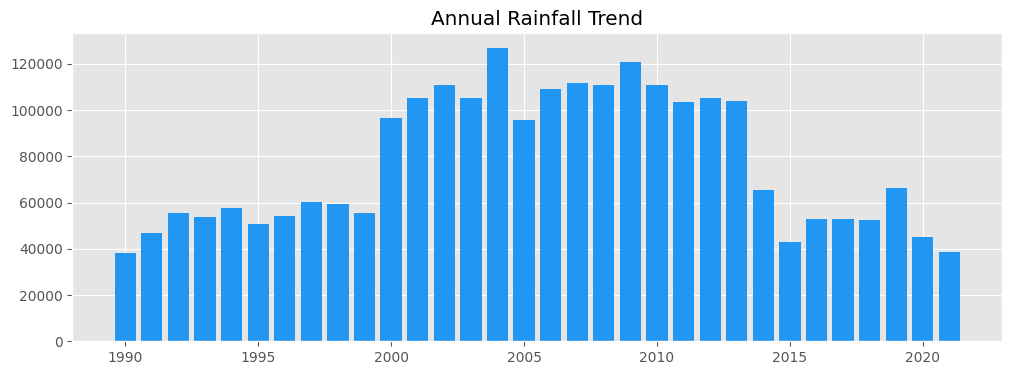

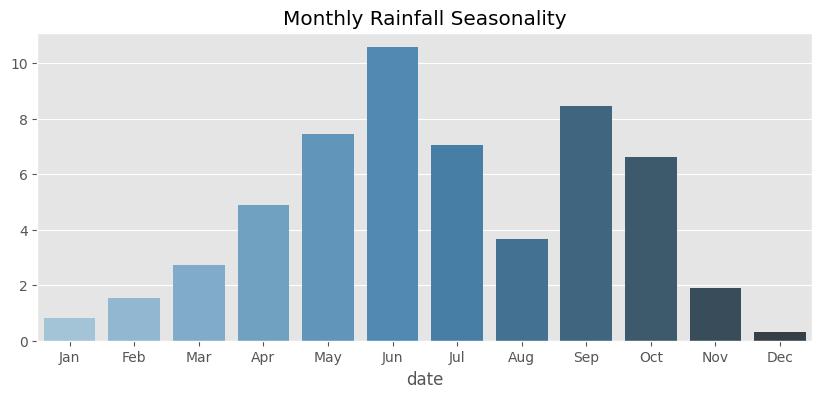

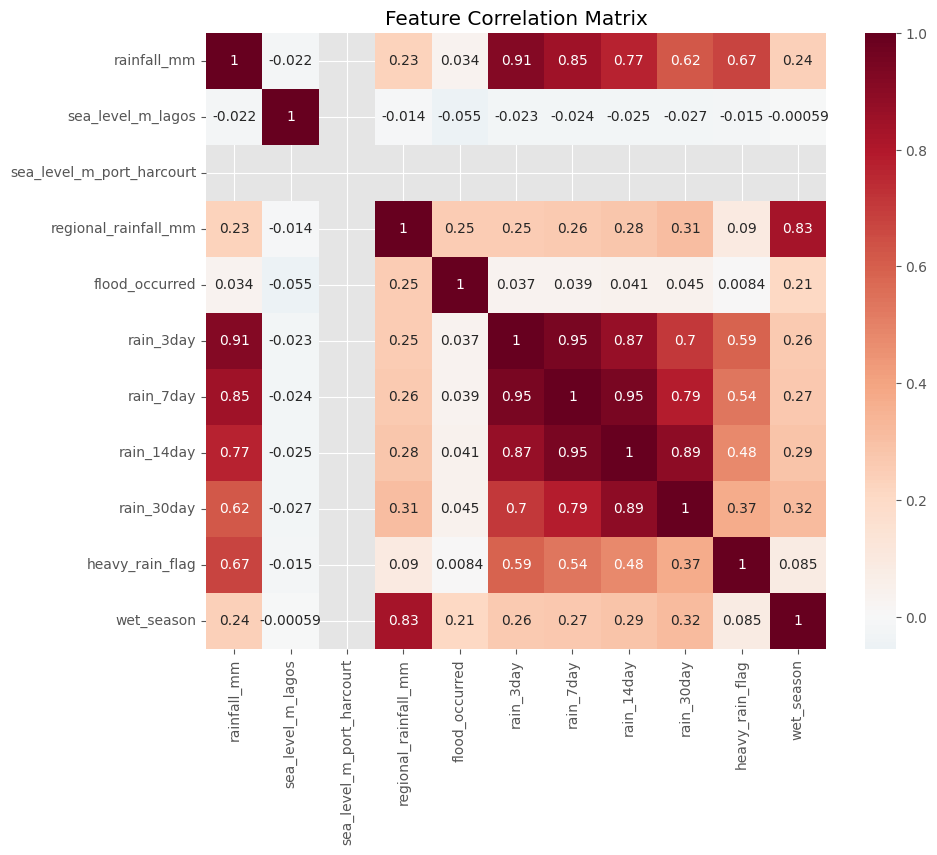

In [9]:
def run_eda(df):
    plt.style.use('ggplot')
    
    # 1. Annual Rainfall
    if "rainfall_mm" in df.columns:
        df['year'] = df['date'].dt.year
        annual = df.groupby("year")["rainfall_mm"].sum()
        plt.figure(figsize=(12, 4))
        plt.bar(annual.index, annual.values, color="#2196F3")
        plt.title("Annual Rainfall Trend")
        plt.savefig(PLOTS / "annual_rain.png")
        plt.show()

    # 2. Seasonality
    if "rainfall_mm" in df.columns:
        monthly = df.groupby(df['date'].dt.month)["rainfall_mm"].mean()
        plt.figure(figsize=(10, 4))
        sns.barplot(x=monthly.index, y=monthly.values, palette="Blues_d")
        plt.title("Monthly Rainfall Seasonality")
        plt.xticks(range(12), ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
        plt.savefig(PLOTS / "seasonality.png")
        plt.show()

    # 3. Correlation Heatmap
    numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['year','month','day_of_year'], errors='ignore')
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_df.corr(), annot=True, cmap="RdBu_r", center=0)
    plt.title("Feature Correlation Matrix")
    plt.savefig(PLOTS / "correlation.png")
    plt.show()

if 'master' in locals(): run_eda(master)

## 3. Model Training (XGBoost & LSTM)
Train a tabular XGBoost classifier and a sequence-based LSTM model.

In [10]:
from xgboost import XGBClassifier
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
    HAS_TF = True
except ImportError:
    HAS_TF = False

def prepare_model_data(df):
    features = ["rainfall_mm", "rain_3day", "rain_7day", "rain_14day", "rain_30day", "heavy_rain_flag", 
                "sea_level_m_lagos", "sea_level_m_port_harcourt", "tide_level_m", "tide_7day_mean", "high_tide_flag",
                "wet_season", "month", "day_of_year"]
    features = [c for c in features if c in df.columns]
    
    X = df[features].fillna(df[features].median())
    y = df["flood_occurred"].fillna(0).astype(int)
    
    split = int(len(df) * 0.8)
    scaler = StandardScaler()
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test, features, scaler

if 'master' in locals() and "flood_occurred" in master.columns:
    X_train, X_test, y_train, y_test, FEATURE_COLS, scaler = prepare_model_data(master)
    
    # XGBoost
    print("\n Training XGBoost Model...")
    scale = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    xgb = XGBClassifier(n_estimators=100, scale_pos_weight=scale, random_state=42)
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)
    print(classification_report(y_test, y_pred))
    
    with open(MODELS / "xgboost_flood_model.pkl", "wb") as f: pickle.dump(xgb, f)
    with open(MODELS / "scaler.pkl", "wb") as f: pickle.dump(scaler, f)
    with open(MODELS / "model_meta.json", "w") as f: json.dump({"feature_cols": FEATURE_COLS}, f)
    
    # LSTM (Optional/Simplified)
    if HAS_TF:
        print("\n Training LSTM Model (Simplified)...")
        def create_seq(X, y, win=14):
            Xs, ys = [], []
            for i in range(win, len(X)):
                Xs.append(X[i-win:i]); ys.append(y.iloc[i])
            return np.array(Xs), np.array(ys)
        
        X_s_t, y_s_t = create_seq(pd.DataFrame(X_train), y_train.reset_index(drop=True))
        model = Sequential([
            LSTM(32, input_shape=(14, len(FEATURE_COLS))),
            Dense(1, activation="sigmoid")
        ])
        model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
        model.fit(X_s_t, y_s_t, epochs=5, batch_size=32, verbose=0)
        print(" LSTM training complete (5 epochs).")


🚀 Training XGBoost Model...
              precision    recall  f1-score   support

           0       0.98      0.75      0.85     96192
           1       0.22      0.81      0.35      8416

    accuracy                           0.75    104608
   macro avg       0.60      0.78      0.60    104608
weighted avg       0.92      0.75      0.81    104608


 Training LSTM Model (Simplified)...
 LSTM training complete (5 epochs).


## 4. Early Warning System
Deploy the model to generate alerts and reports.

In [13]:
def get_alert_info(prob):
    if prob < 0.35: return "GREEN", "🟢", "Low Risk", "Normal operations."
    if prob < 0.65: return "AMBER", "🟡", "Moderate Risk", "Prepare drainage, issue advisory."
    return "RED", "🔴", "HIGH RISK", "IMMEDIATE ACTION: Evacuate low areas."

def generate_report(df, model, scaler, features):
    X_scaled = scaler.transform(df[features].fillna(df[features].median()))
    probs = model.predict_proba(X_scaled)[:, 1]
    
    df["flood_probability"] = probs
    today = df.iloc[-1]
    lvl, emo, lab, act = get_alert_info(today["flood_probability"])
    
    report = f"""
    FLOOD ALERT REPORT
    Date: {today['date'].strftime('%Y-%m-%d')}
    Risk Level: {emo} {lab} ({today['flood_probability']:.1%})
    Recommended Action: {act}
    """
    print(report)
    df[["date", "flood_probability"]].tail(10).to_csv(OUTPUTS / "recent_forecasts.csv")

if 'master' in locals() and 'xgb' in locals():
    generate_report(master, xgb, scaler, FEATURE_COLS)


    FLOOD ALERT REPORT
    Date: 2021-09-30
    Risk Level: 🔴 HIGH RISK (66.5%)
    Recommended Action: IMMEDIATE ACTION: Evacuate low areas.
    
